<a href="https://colab.research.google.com/github/Obscuriosity/Programming_For_Data_Analysis/blob/main/ST20214513_CMP7005_PRAC_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Programming for Data Analysis CMP7005**

Tony WIllett ST20214513

In [2]:
!pip install streamlit
!pip install --upgrade streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import os
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

!git config --global user.name "Obscuriosity"
!git config --global user.email "tony.obscuriosity@gmail.com"
username = "Obscuriosity"
repo = "Programming_for_Data_Analysis"
!git clone https://github.com/{username}/{repo}


Cloning into 'Programming_for_Data_Analysis'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 41 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 3.82 MiB | 4.41 MiB/s, done.
Resolving deltas: 100% (17/17), done.


# Task 1: Data Selection & Handling

Here the monitoring stations are chosen and the data for the four are loaded into the project and are joined into one dataset.


Choose Locations and upload data.
Monitoring Station:

**Dongsi DS** - This urban monitoring station seems to be closest to the centre of Beijing

**Gucheng GC** - This Station is furthest from DS whilst still being an urban station.

**Changpingzhen CP** - This was chosen because it is an suburban station but is still close to the urban area. It may give information about the influence of the urban area on the local environs.

**Huairouzhen HR** - This station appears to be the furthest suburban station from the urban centre.

Together these four will give a sort of cross section going form the urban centre, out to the furthest suburbs. An attmpt was made to get four stations in a straight line from the centre to the edge but the position of the stations did not permit this. This virtual cross section will have to serve the purpose.


In [4]:
# Load monitoring station data CSV and make pandas dataframes
df_dongsi = pd.read_csv('/content/Programming_for_Data_Analysis/Data/PRSA_Data_Dongsi_20130301-20170228.csv')
df_Gucheng = pd.read_csv('/content/Programming_for_Data_Analysis/Data/PRSA_Data_Gucheng_20130301-20170228.csv') # Corrected file path
df_Changpingzhen = pd.read_csv('/content/Programming_for_Data_Analysis/Data/PRSA_Data_Changping_20130301-20170228.csv')
df_Huairou = pd.read_csv('/content/Programming_for_Data_Analysis/Data/PRSA_Data_Huairou_20130301-20170228.csv')

# Combine dataframes into one
df = pd.concat([df_dongsi, df_Gucheng, df_Changpingzhen, df_Huairou])
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


# Task 2: Exploratory Data Analysis (EDA)

###2.1 Data Understanding
Here various tools built into pandasa are used to have a look at the raw data.
Starting with a look at the column headings and understanding what they relate to.

Before looking at the data frame in any detail it is worth establishing what the column headings pertain to.

**No** - is simply the row number.

**Year, Month, day and Hour** - are self explanatory records of when the samples were taken

**PM2.5** - are particulate matter below 2.5 micrometres measured in ug/m^3, these fine particles can penetrate deeply into the lungs.

**PM10** - This value includes PM2.5 and is a record of particulate matter below 10 micrometres measured in ug/m^3. One should subtract the PM2.5 value to get coarse and fine particles separately.

**SO2** - Sulphur Dioxide  measured in ug/m^3.

**NO2** - Nitrogen Dioxide,  measured in ug/m^3.

**CO** - Carbon Monoxide  measured in ug/m^3.

**O3** - Ozone concentration measured in ug/m^3.

**TEMP** - is the local temperature in Celsius.

**PRES** - is local air pressure in hPa.

**DEWP** - is the dew point in Celsius and gives a good indication of humidity, a high value indicates high humidity.

**RAIN** - gives rainfall measured in mm.

**wd** - indicates the wind direction using compass points.

**WSPM** - is the wind speed in m/s.

**station** - shows the station where the readings were taken.


In [5]:
# Using Pandas to gain insight into the raw data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140256 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    137133 non-null  float64
 6   PM10     137963 non-null  float64
 7   SO2      137478 non-null  float64
 8   NO2      135681 non-null  float64
 9   CO       132715 non-null  float64
 10  O3       137108 non-null  float64
 11  TEMP     140081 non-null  float64
 12  PRES     140083 non-null  float64
 13  DEWP     140079 non-null  float64
 14  RAIN     140087 non-null  float64
 15  wd       139577 non-null  object 
 16  WSPM     140108 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 20.3+ MB


The info function shows that there are 140,256 entries and straight away reveals that not all columns contain the full count of data. We can safely assume that the C0 column, which has the fewest non-null entries (132,595) therefore contains the most null data. As would be expected, the date, time and station name data all contin the full count wheras the actual readings all fall short by varying amounts, this may be due to faulty sensors or any number of reasons.

In [6]:
# some pandas functions to elicit individual data insights
print(df.shape)
print(df.columns)
print(df.dtypes)

(140256, 18)
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object


The shape command confirms that there are 140,256 entries and 18 columns. The columns and dtypes functions repeat the information gained form the info() function, showing the column names and the data types.

###2.2 Data preprocessing:
Here the necessary data preprocessing steps are carried out, handling missing values adjusting datetime components to aid sorting and creating a data frame of AQI levels.



Missing Values
No            0
year          0
month         0
day           0
hour          0
PM2.5      3123
PM10       2293
SO2        2778
NO2        4575
CO         7541
O3         3148
TEMP        175
PRES        173
DEWP        177
RAIN        169
wd          679
WSPM        148
station       0
dtype: int64


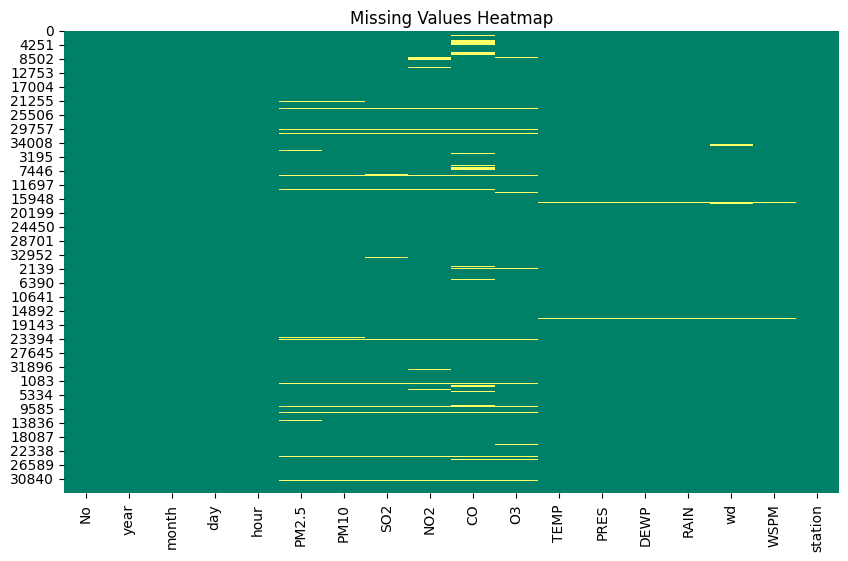

In [14]:
# a look at the null values in more detail
print("Missing Values")
print(df.isnull().sum())
# create heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='summer')
plt.title('Missing Values Heatmap')
plt.show()

The sum of null values command shows that CO indeed contains the most null entries. 7,541 represents just 5.4% of the total 140256 readings. the next highest content of null values is 4,575 for NO2 and equates to 3.3%. This means that the data is quite complete and that imputing values, even if slightly inaccurate will not adversely affect the conclusions drawn. Nonetheless imputation will be done to preserve data integrity as much as possible.

In [10]:
# Create copy for station specific imputation:
df_station_imputed = df.copy()

station-wise imputation: iterate through each unique station in the dataset. For each station:
1.  Filter the DataFrame to include only data for that specific station.
2.  Again dentify numerical columns with missing values within that station's data.
3.  Apply IterativeImputer to fill numerical missing values.
4.  Impute the 'wd' (wind direction) column with the mode specific to that station.
5.  Store the imputed station data.
Finally, all the imputed station dataframes will be combined back into a single DataFrame.

['Dongsi' 'Gucheng' 'Changping' 'Huairou']
Processing station: Dongsi
Processing station: Gucheng
Processing station: Changping
Processing station: Huairou

Missing values after station-wise imputation:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64


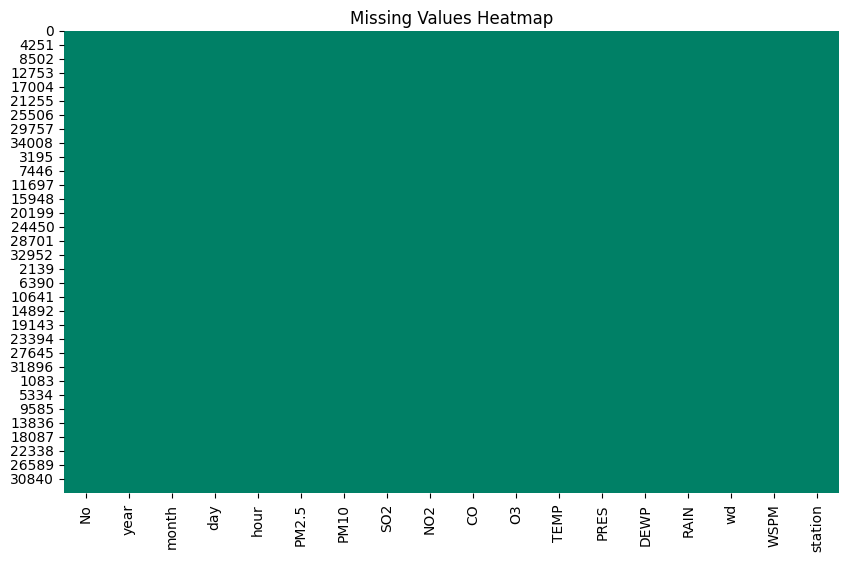

In [13]:
# Creat e four dfs one for aeach station, impute null values.
unique_stations = df_station_imputed['station'].unique()
print(unique_stations)
imputed_dfs_list = []

for station_name in unique_stations:
    print(f"Processing station: {station_name}")
    station_df = df_station_imputed[df_station_imputed['station'] == station_name].copy()

    # Identify numerical columns with missing values for current station
    numerical_cols_with_missing_station = station_df.select_dtypes(include=np.number).columns[station_df.select_dtypes(include=np.number).isnull().any()].tolist()

    if numerical_cols_with_missing_station:
        # Initialize IterativeImputer
        imputer = IterativeImputer(max_iter=10, random_state=0)
        # Apply imputation to columns with missing values for current station
        station_df[numerical_cols_with_missing_station] = imputer.fit_transform(station_df[numerical_cols_with_missing_station])

    # For wind direction, impute with the mode value for current station
    if 'wd' in station_df.columns and station_df['wd'].isnull().any():
        mode_wd_station = station_df['wd'].mode()[0]
        station_df['wd'] = station_df['wd'].fillna(mode_wd_station)

    imputed_dfs_list.append(station_df)

# Join all imputed station dfs back into a single df
df_station_imputed = pd.concat(imputed_dfs_list)

print("\nMissing values after station-wise imputation:")
print(df_station_imputed.isnull().sum())
# create heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df_station_imputed.isnull(), cbar=False, cmap='summer')
plt.title('Missing Values Heatmap')
plt.show()

The df_station_imputed DataFrame now contains all the data with missing values imputed on a station by station basis. The output confirms that there are no remaining missing values, ensuring a complete imputed dataset for further analysis.

In [16]:
# Generate a statistical summary of the imputed DataFrame
print("Statistical Summary of the Imputed DataFrame:")
print(df_station_imputed.describe().T)

Statistical Summary of the Imputed DataFrame:
          count          mean           std          min      25%      50%  \
No     140256.0  17532.500000  10122.141000     1.000000  8766.75  17532.5   
year   140256.0   2014.662560      1.177201  2013.000000  2014.00   2015.0   
month  140256.0      6.522930      3.448715     1.000000     4.00      7.0   
day    140256.0     15.729637      8.800123     1.000000     8.00     16.0   
hour   140256.0     11.500000      6.922211     0.000000     5.75     11.5   
PM2.5  140256.0     77.659911     78.280990   -62.976561    20.00     54.0   
PM10   140256.0    103.878359     90.854072   -18.949772    36.00     82.0   
SO2    140256.0     15.191231     21.007509   -15.882069     2.00      7.0   
NO2    140256.0     46.559050     33.039464   -20.087943    21.00     39.0   
CO     140256.0   1206.869777   1103.311255  -849.901205   500.00    900.0   
O3     140256.0     58.277589     55.702669   -43.316783    14.00     47.0   
TEMP   140256.0   

The description provides statistics for each column in the final DataFrame:

*   **count**: Further confirms the number of observations.
*   **mean**: The average value.
*   **std**: The standard deviation.
*   **min**: The minimum value.
*   **25% (Q1)**: The 25th percentile (first quartile).
*   **50% (Median)**: The 50th percentile (median or second quartile).
*   **75% (Q3)**: The 75th percentile (third quartile).
*   **max**: The maximum value.



###Add datetime and Coarse columns.
After renaming the dataframe df to save on typing, the date is converted to datetime format and the day and hour columns are dropped.
Because the PM10 value contains all particles under 10 micrograms, it necesarily includes the PM2.5 particles. to cet more unique data, a new column iscreated called 'Coarse' this will contain the PM10 value with hte PM2.5 values subtracted giving a clearer picture of the particulate matter in the air.

In [17]:
# turn 'df_station_imputed' back to df for brevity
df = df_station_imputed
# convert date and time to 'datetime'format.
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
# drop day and hour columns as datetime can be used now.
df = df.drop(columns=['day', 'hour'])
# add a 'coarse' column to record the PM10 values with the finer PM2.5 values subtracted.
df['Coarse'] = df['PM10'] - df['PM2.5']
col = df.pop('Coarse')
df.insert(5, col.name, col)
df.head()

,No,year,month,PM2.5,PM10,Coarse,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,9.0,9.0,0.0,3.00000,17.000000,300.000000,89.000000,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00
1,2,2013,3,4.0,4.0,0.0,3.00000,16.000000,300.000000,88.000000,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01 01:00:00
2,3,2013,3,7.0,7.0,0.0,16.87933,17.000000,300.000000,60.000000,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,2013-03-01 02:00:00
3,4,2013,3,3.0,3.0,0.0,5.00000,18.000000,380.623095,45.949218,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,2013-03-01 03:00:00
4,5,2013,3,3.0,3.0,0.0,7.00000,12.953987,200.000000,84.000000,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,2013-03-01 04:00:00


With the addition of the Coarse column we can see from the 'head' above that the PM10 values for the first five entries were actually just the PM2.5 readings. The following graphs show the PM2.5 ans Coarse values for each station.

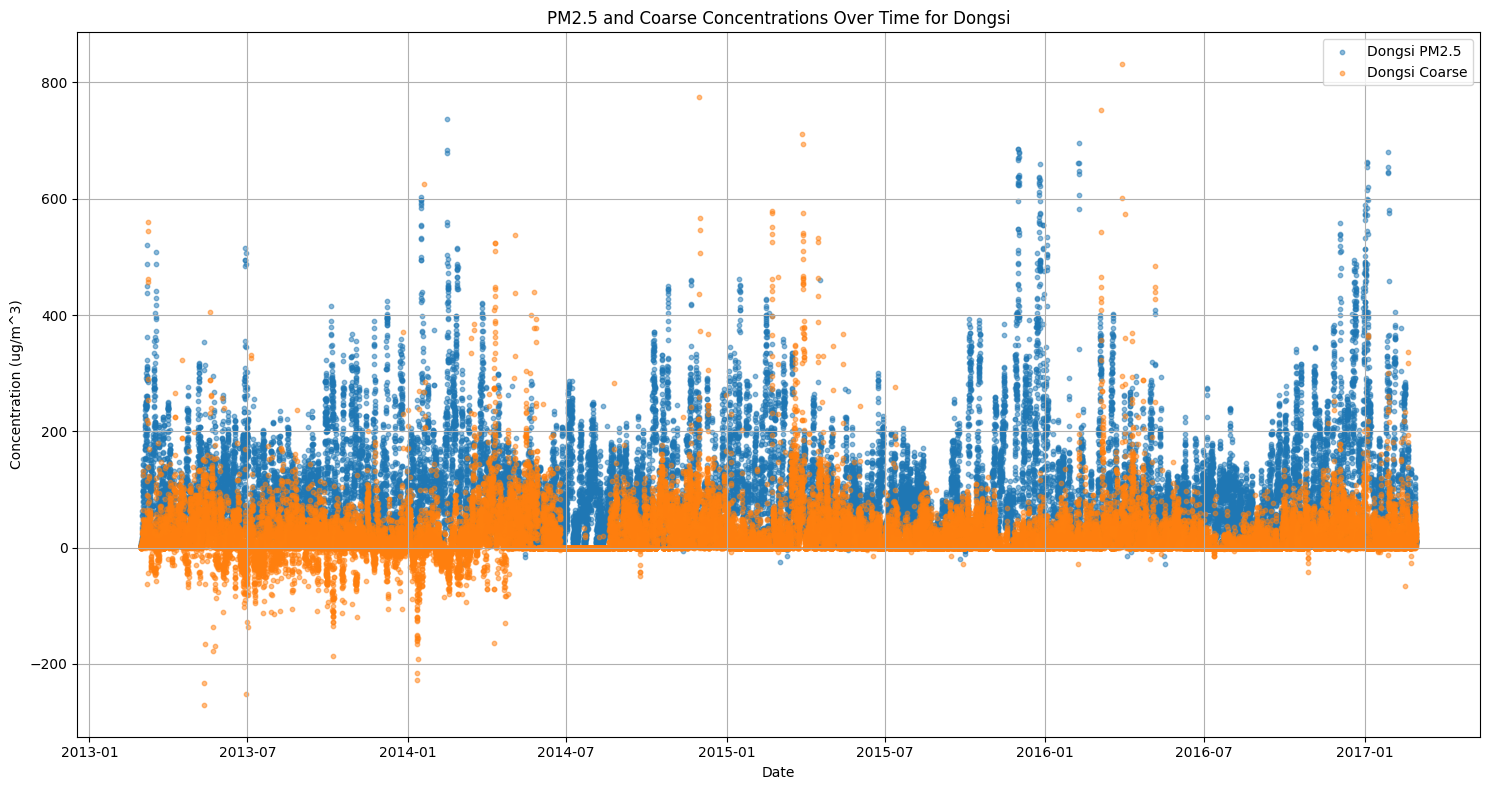

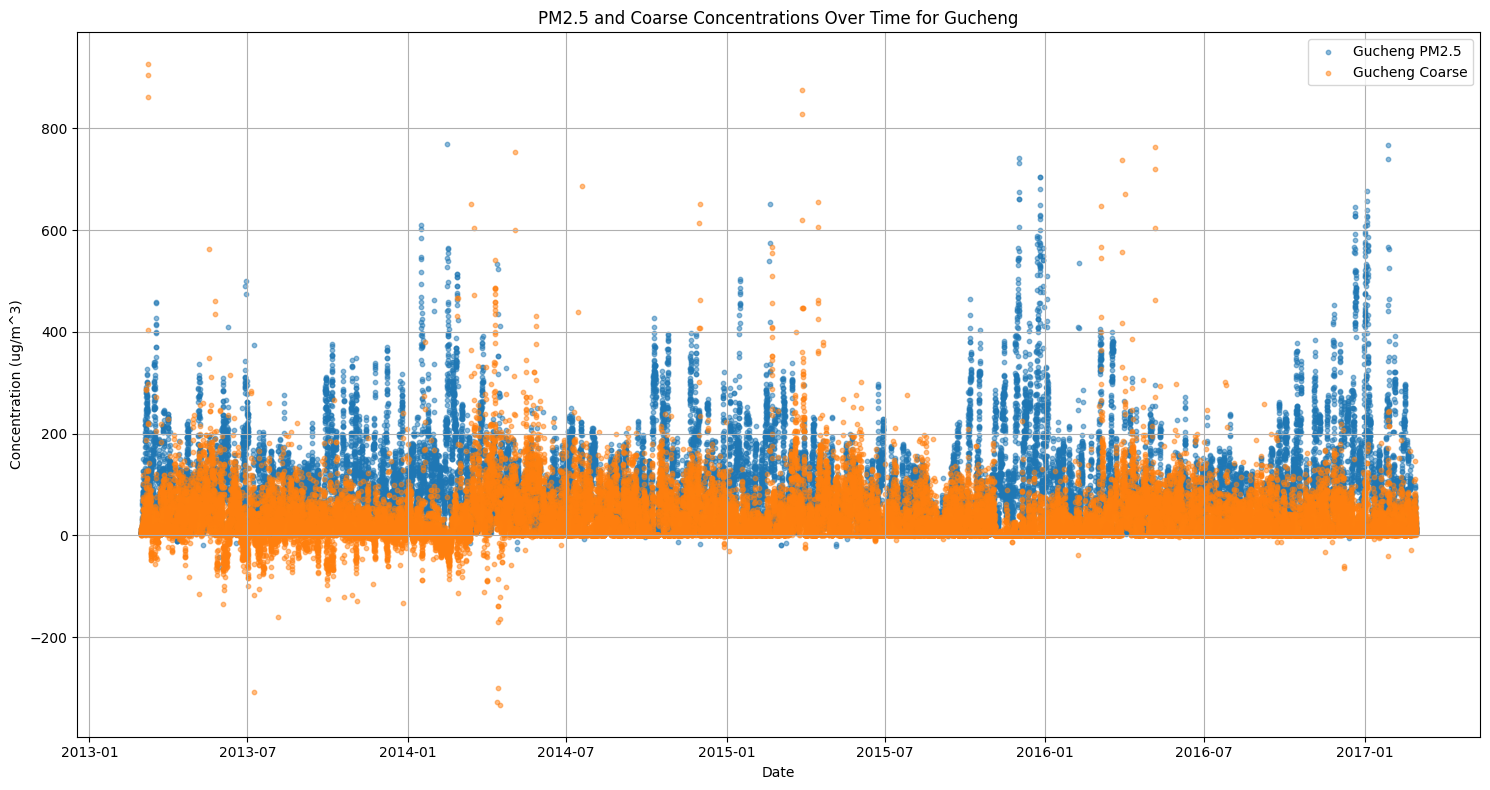

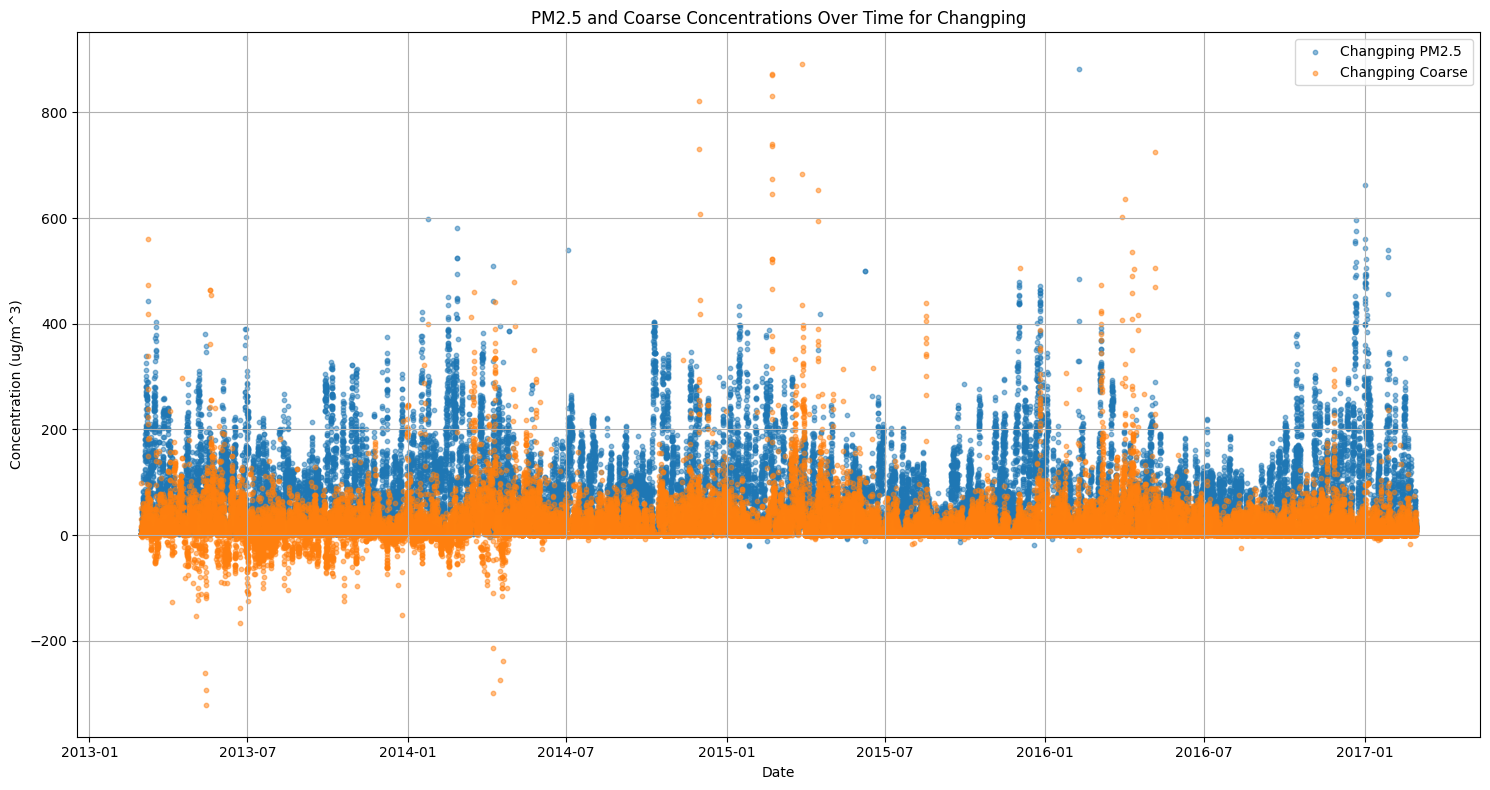

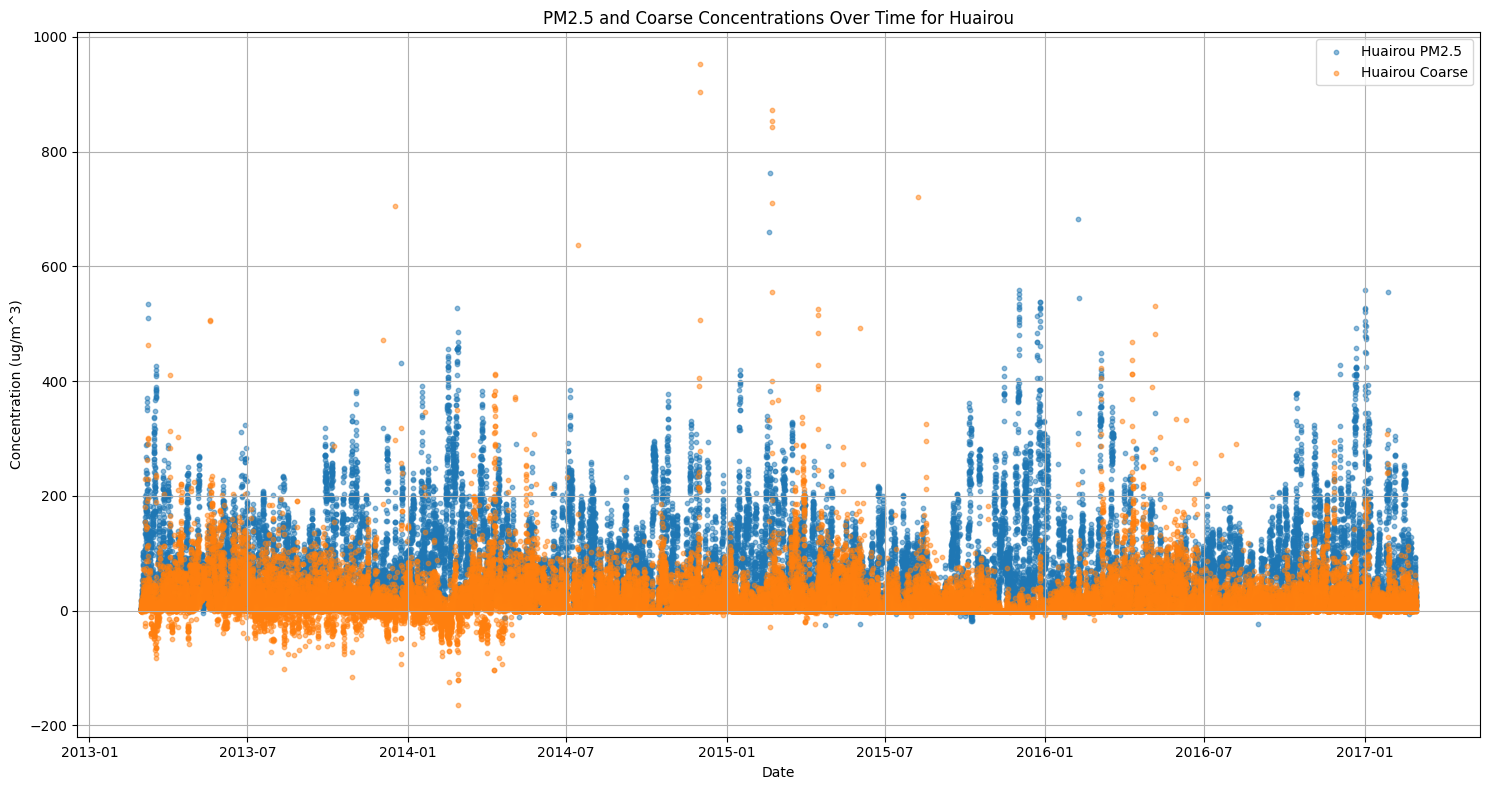

In [21]:
# create four graphs, one for each station, plotting Coarse and PM2.5 values over time
for station_name in df['station'].unique():
    plt.figure(figsize=(15, 8))
    station_df = df[df['station'] == station_name]
    # Line plots
    # plt.plot(station_df['datetime'], station_df['PM2.5'], label=f'{station_name} PM2.5 - Line')
    # plt.plot(station_df['datetime'], station_df['Coarse'], label=f'{station_name} Coarse - Line')

    # Scatter plots
    plt.scatter(station_df['datetime'], station_df['PM2.5'], label=f'{station_name} PM2.5', alpha=0.5, s=10)
    plt.scatter(station_df['datetime'], station_df['Coarse'], label=f'{station_name} Coarse', alpha=0.5, s=10)

    plt.xlabel('Date')
    plt.ylabel('Concentration (ug/m^3)')
    plt.title(f'PM2.5 and Coarse Concentrations Over Time for {station_name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

###Coarse and PM2.5 data visualisation
The graphs above show that whilst the coarse concentrations can get high, the finer PM2.5 particles, which are more injurious to health, are consistently higher.

### Daily Air Quality Index (AQI).

The daily AQI seems like a good metric for air quality (this is probably why it is used). It neatly uses all of our pollutant data and gives an excellent comparison, day to day. It is a shame that there is not an international standard for this metric, this would make worldwide comparisons easier.

Calculating daily AQI results for each station based on the Chinese standard from (https://aqihub.info/indices/china). Create a function to calculate the Individual Air Quality Index (IAQI) for each pollutant, for this, the breakpoints for each pollutant are reqiuired. Then, aggregate the hourly data to daily averages per station and apply this function to compute the daily IAQI for each pollutant, finally determining the overall daily AQI.

In [22]:
# function to calculate Individual Air Quality Index (IAQI)
def calculate_iaqi(C, pollutant_name):

    breakpoints = {
        'PM2.5': { # Units: ug/m^3 (24-hour average for AQI)
            'C': [0, 35, 75, 115, 150, 250, 500],
            'IAQI': [0, 50, 100, 150, 200, 300, 500]
        },
        'PM10': { # Units: ug/m^3 (24-hour average for AQI)
            'C': [0, 50, 150, 250, 350, 420, 600],
            'IAQI': [0, 50, 100, 150, 200, 300, 500]
        },
        'SO2': { # Units: ug/m^3 (24-hour average for AQI, adjusted for 1601-2100 breakpoint)
            'C': [0, 50, 150, 475, 800, 1600, 2100, 2620],
            'IAQI': [0, 50, 100, 150, 200, 300, 400, 500]
        },
        'NO2': { # Units: ug/m^3 (24-hour average for AQI, but 1-hour breakpoints for higher levels)
            'C': [0, 40, 80, 180, 280, 565, 1130],
            'IAQI': [0, 50, 100, 150, 200, 300, 500]
        },
        'CO': { # Units: mg/m^3 (24-hour average for AQI)
            'C': [0, 2, 4, 14, 24, 36, 60],
            'IAQI': [0, 50, 100, 150, 200, 300, 500]
        },
        'O3': { # Units: ug/m^3 (8-hour average for AQI, but 1-hour breakpoints for higher levels)
            'C': [0, 100, 160, 215, 265, 800, 1200],
            'IAQI': [0, 50, 100, 150, 200, 300, 500]
        }
    }

    if pollutant_name not in breakpoints:
        return np.nan

    bp_c = breakpoints[pollutant_name]['C']
    bp_iaqi = breakpoints[pollutant_name]['IAQI']

    # treat negative concentrations as 0 for calculation
    if C < 0:
        C = 0

    # find the breakpoint interval
    for i in range(len(bp_c) - 1):
        if bp_c[i] <= C < bp_c[i+1]:
            C_low = bp_c[i]
            C_high = bp_c[i+1]
            IAQI_low = bp_iaqi[i]
            IAQI_high = bp_iaqi[i+1]

            if C_high == C_low:
                return IAQI_low

            iaqi = ((IAQI_high - IAQI_low) / (C_high - C_low)) * (C - C_low) + IAQI_low
            return round(iaqi)

    # if concentration is greater than or equal to the highest breakpoint
    if C >= bp_c[-1]:
        return bp_iaqi[-1]

    return np.nan

# create a daily DataFrame by grouping by station and date, and taking the mean of relevant numerical columns
df_daily = df.groupby(['station', df['datetime'].dt.date]).agg({
    'PM2.5': 'mean',
    'PM10': 'mean',
    'SO2': 'mean',
    'NO2': 'mean',
    'CO': 'mean', # CO is still in ug/m^3 at this stage
    'O3': 'mean',
    'TEMP': 'mean',
    'PRES': 'mean',
    'DEWP': 'mean',
    'RAIN': 'sum', # Rain is typically summed for daily totals
    'WSPM': 'mean' # Wind speed is averaged
}).reset_index()

df_daily = df_daily.rename(columns={'datetime': 'date'})

# <IMPORTANT> convert CO from ug/m^3 to mg/m^3 before calculating IAQI for CO
df_daily['CO'] = df_daily['CO'] / 1000.0

# list of pollutants for which to calculate IAQI
pollutants_for_aqi_daily = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# calculate IAQI for each pollutant in the daily df
for p in pollutants_for_aqi_daily:
    if p in df_daily.columns:
        df_daily[f'IAQI_{p}'] = df_daily[p].apply(lambda x: calculate_iaqi(x, p))
    else:
        print(f"Warning: Pollutant '{p}' not found in daily DataFrame.")

# calculate the overall Daily AQI as the maximum of all individual AQIs
iaqi_columns_daily = [f'IAQI_{p}' for p in pollutants_for_aqi_daily if f'IAQI_{p}' in df_daily.columns]

if iaqi_columns_daily:
    df_daily['Daily_AQI'] = df_daily[iaqi_columns_daily].max(axis=1)
else:
    df_daily['Daily_AQI'] = np.nan

print("DataFrame head with calculated Daily IAQI and overall Daily AQI:")
display(df_daily[['station', 'date', 'PM2.5', 'IAQI_PM2.5', 'PM10', 'IAQI_PM10', 'SO2', 'IAQI_SO2', 'NO2', 'IAQI_NO2', 'CO', 'IAQI_CO', 'O3', 'IAQI_O3', 'Daily_AQI']].head())

DataFrame head with calculated Daily IAQI and overall Daily AQI:


,station,date,PM2.5,IAQI_PM2.5,PM10,IAQI_PM10,SO2,IAQI_SO2,NO2,IAQI_NO2,CO,IAQI_CO,O3,IAQI_O3,Daily_AQI
0,Changping,2013-03-01,5.083333,7,18.958333,19,16.041667,16,15.333333,19,0.387500,10,77.791667,39,39
1,Changping,2013-03-02,33.333333,48,39.833333,40,40.770657,41,59.677172,75,0.969573,24,27.872445,14,75
2,Changping,2013-03-03,57.541667,78,82.666667,66,37.875000,38,58.791667,73,1.254000,31,31.333333,16,78
3,Changping,2013-03-04,20.791667,30,36.166667,36,22.375000,22,30.250000,38,0.583333,15,66.458333,33,38
4,Changping,2013-03-05,106.958333,140,125.166667,88,50.708333,50,75.291667,94,1.641333,41,88.750000,44,140


Initially these calculations all came out as 500 for every station, every day, This came from the CO values which were in ug/m^3 wheras the calculation requires they are in mg/m^3. After correcting this the graph below was produced, overlaying each station over time.

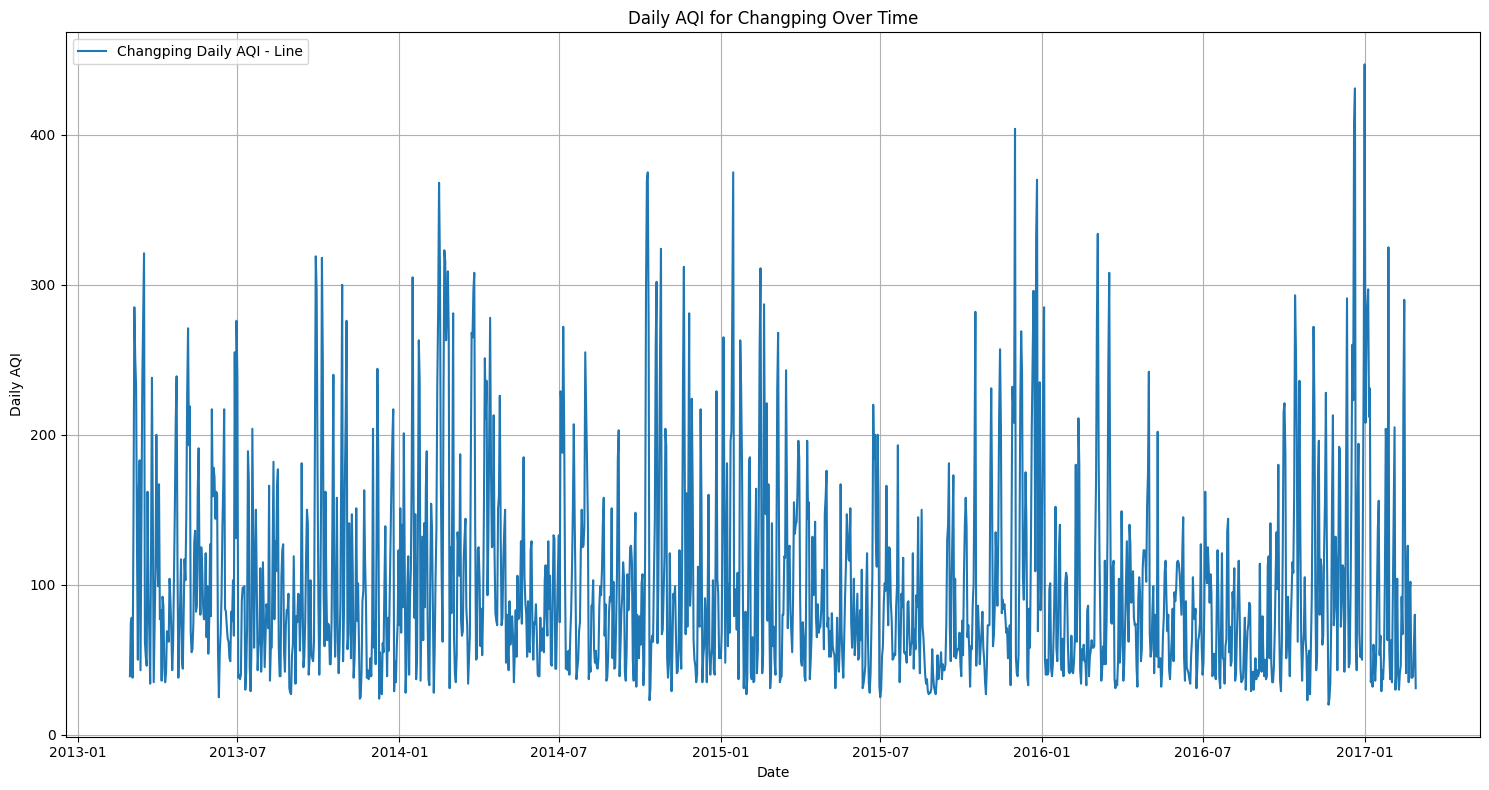

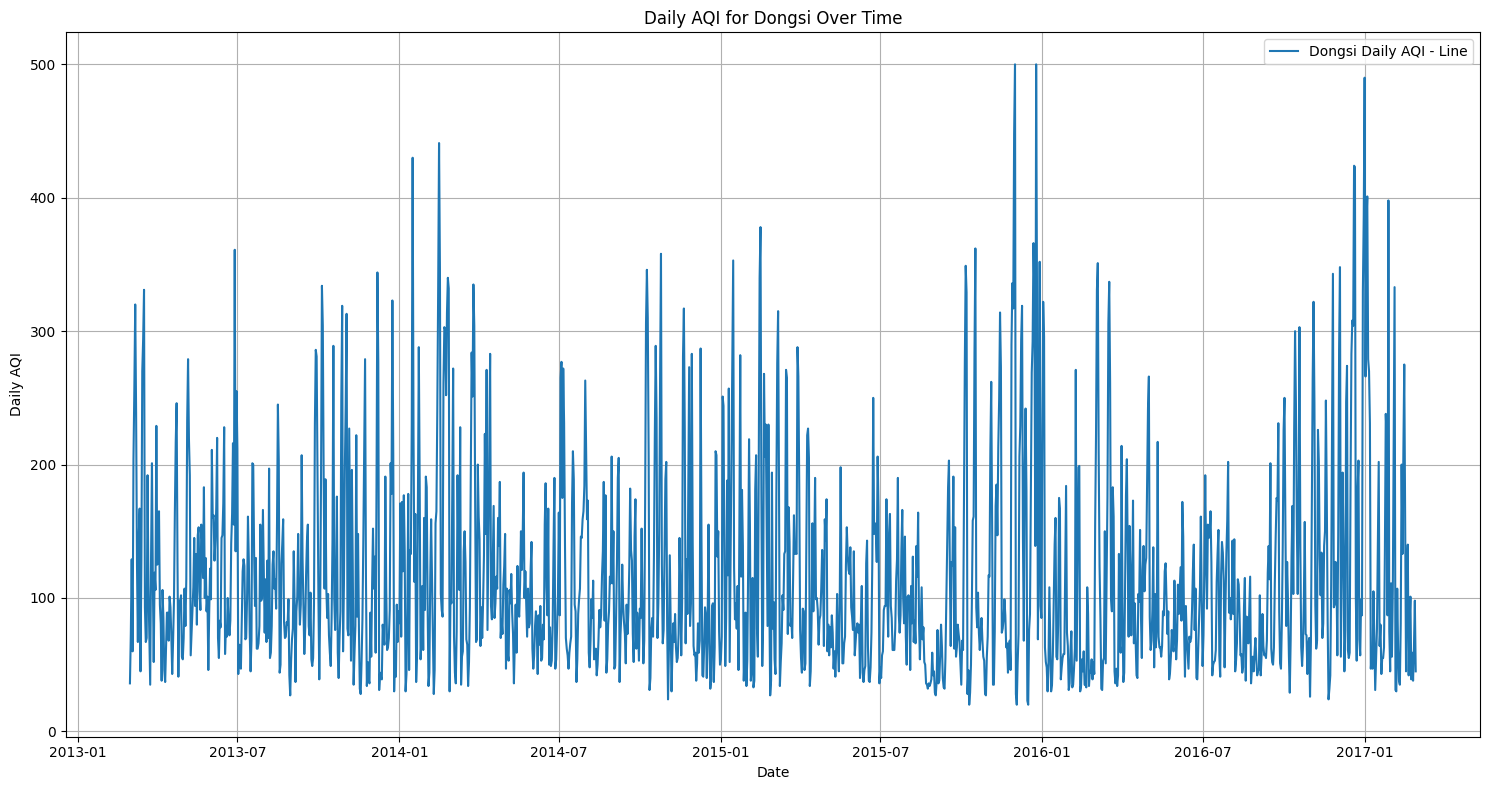

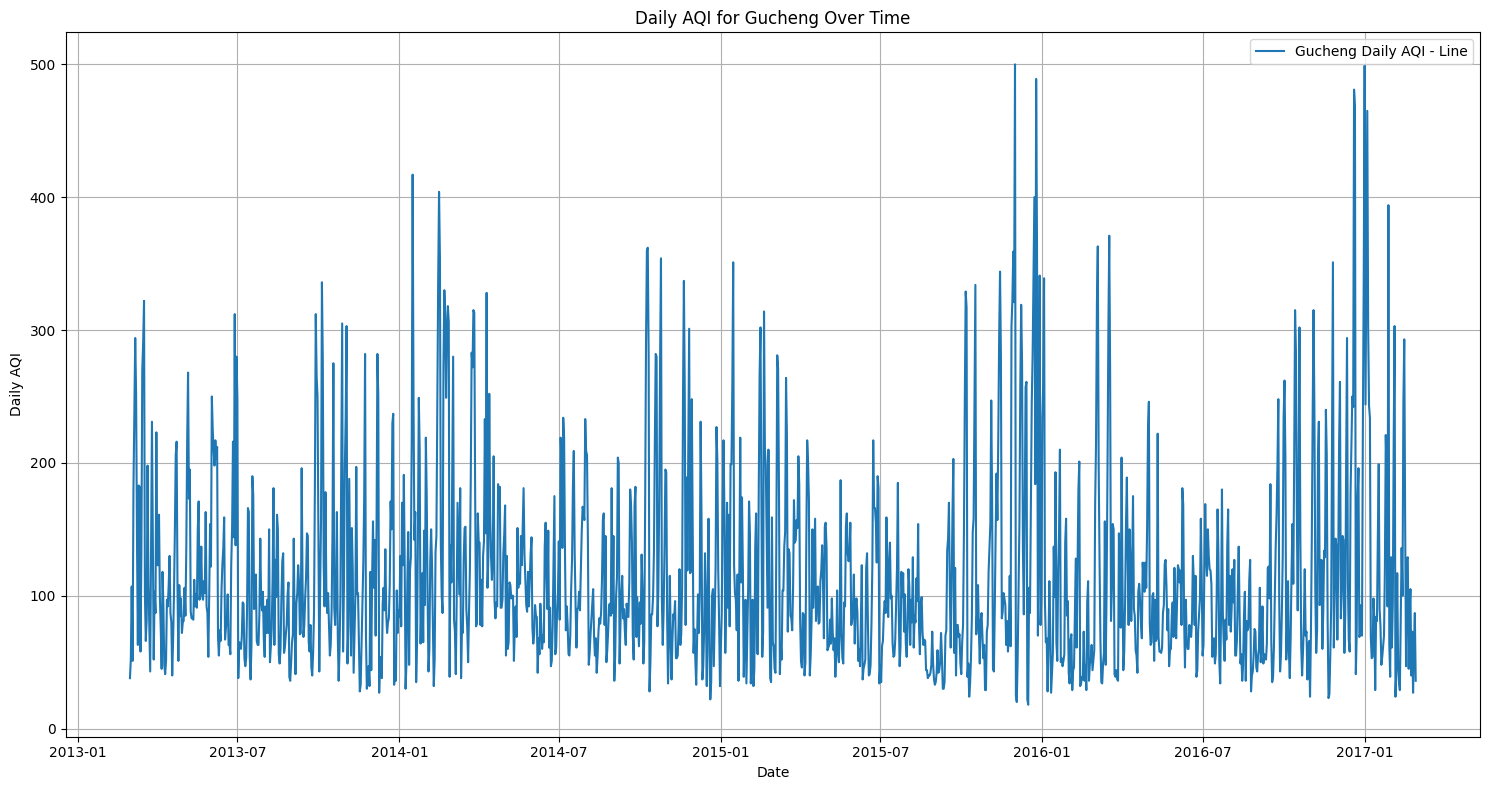

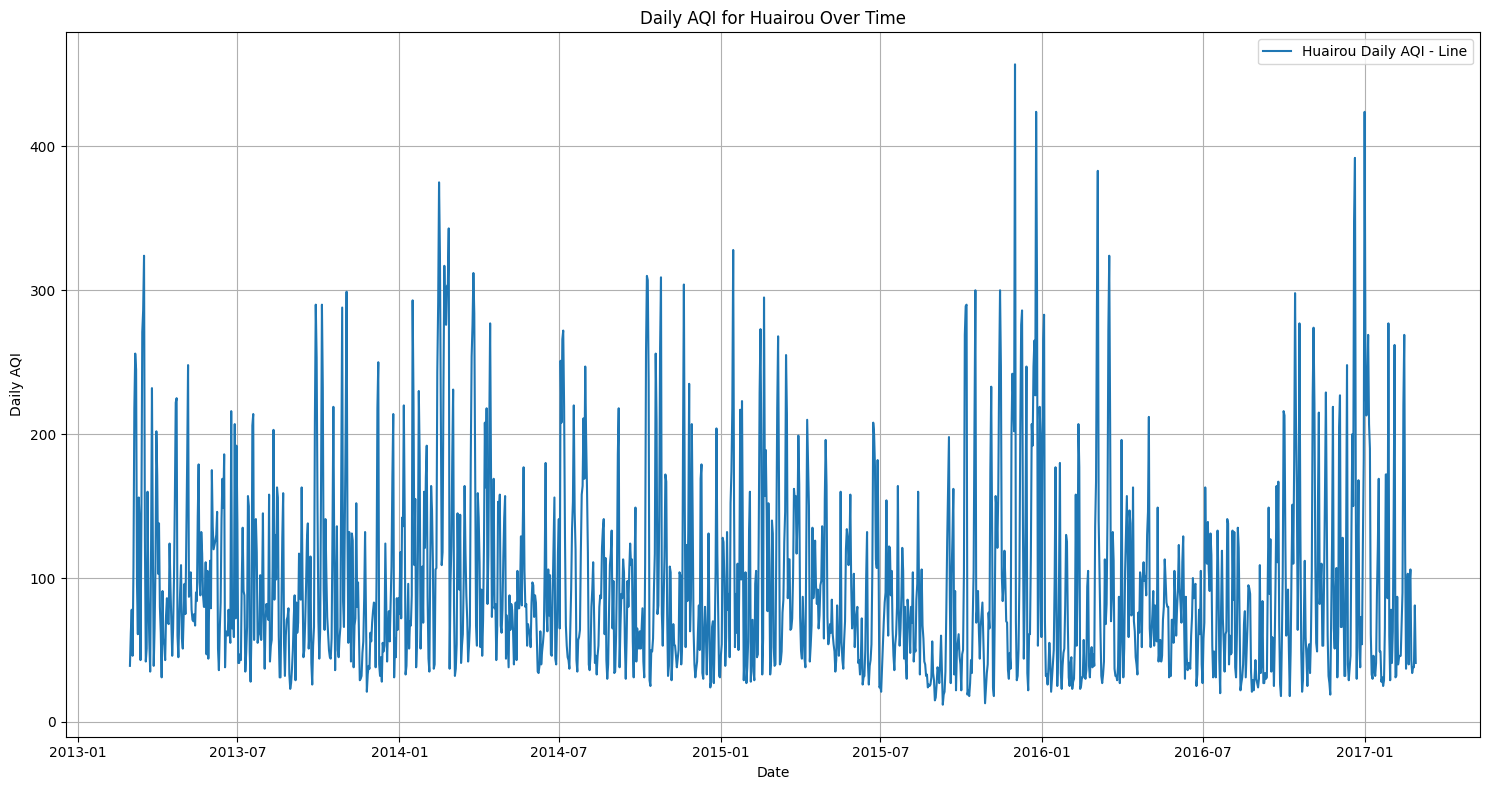

In [24]:
# plot aqi data for each station over time, with options for scatter or line plots
for station_name in df_daily['station'].unique():
    plt.figure(figsize=(15, 8))
    station_df_daily = df_daily[df_daily['station'] == station_name]

    # Line plot
    plt.plot(station_df_daily['date'], station_df_daily['Daily_AQI'], label=f'{station_name} Daily AQI - Line')

    # Scatter plot
    # plt.scatter(station_df_daily['date'], station_df_daily['Daily_AQI'], label=f'{station_name} Daily AQI', alpha=0.5, s=10)

    plt.xlabel('Date')
    plt.ylabel('Daily AQI')
    plt.title(f'Daily AQI for {station_name} Over Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

###Initial conclusions

An initial look at the AQI data for the four stations shows peaks in leading up to and following January, with corresponding troughs in the middle of the year.

https://aqihub.info/indices/china

AQI

###2.3 Statistical/Computational Analysis & Visualisation
Perform the necessary steps such as univariate (distribution of pollutants & meteorological variables),
bivariate(e.g. relationships such as PM2.5 vs. Temp, NO2 vs. O3 but not limited to these), and
multivariate analysis (correlation, heatmaps, pairplots), statistical summary, and visualizing the data
(Various charts and graphs, such as bar charts, line charts and scatter plots) that will help in
understanding relationships between variables and to gain important insights from data. Interpret the
key results to demonstrate understanding generated from statistical and visual analysis.


• Explore the dataset however you find meaningful. You may examine different variables, compare
stations, investigate temporal behaviours, or analyse interactions between pollutants and
meteorological factors. Choose the approaches that you believe best help you understand and interpret
the dataset, and present the insights you consider most relevant

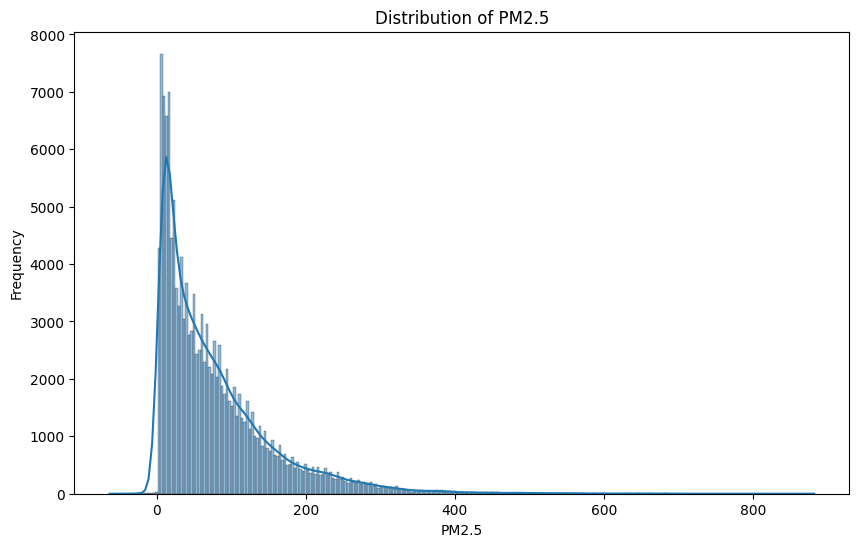

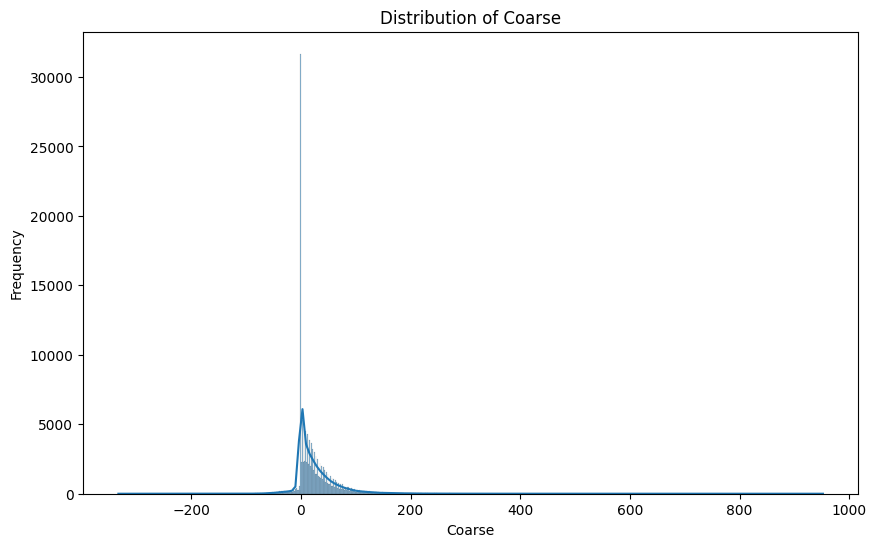

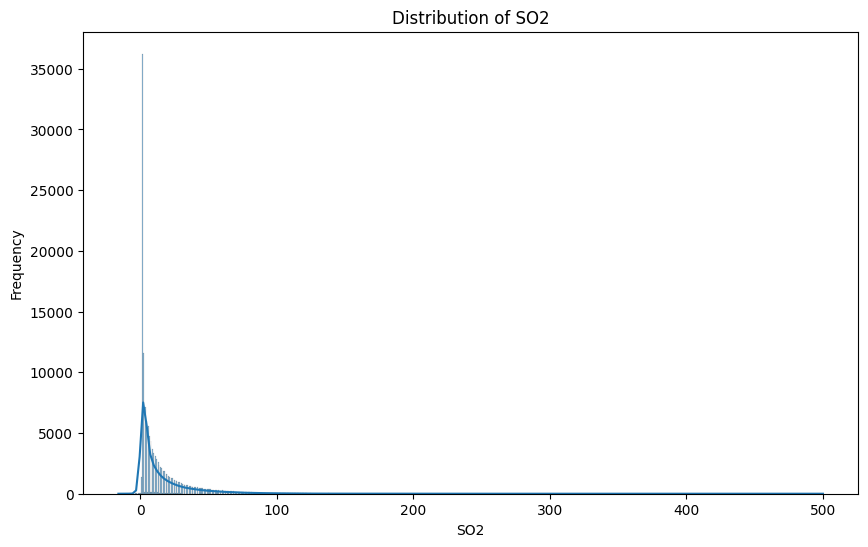

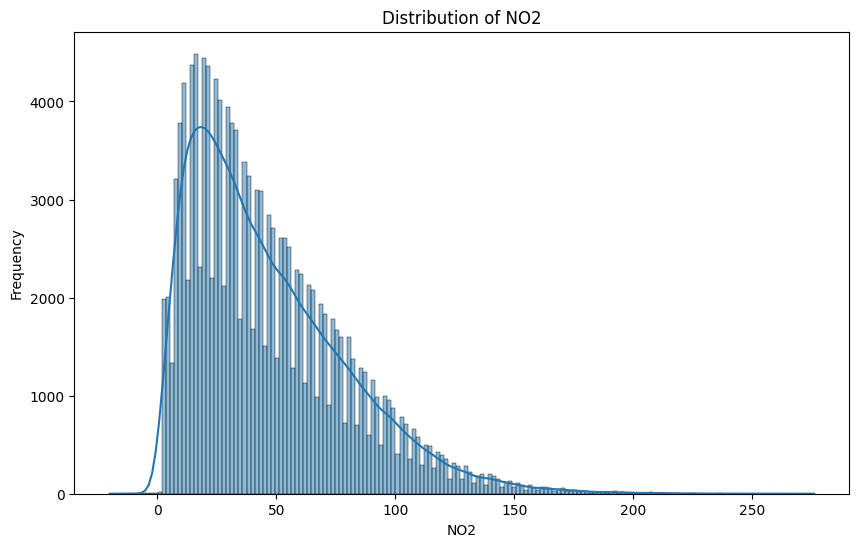

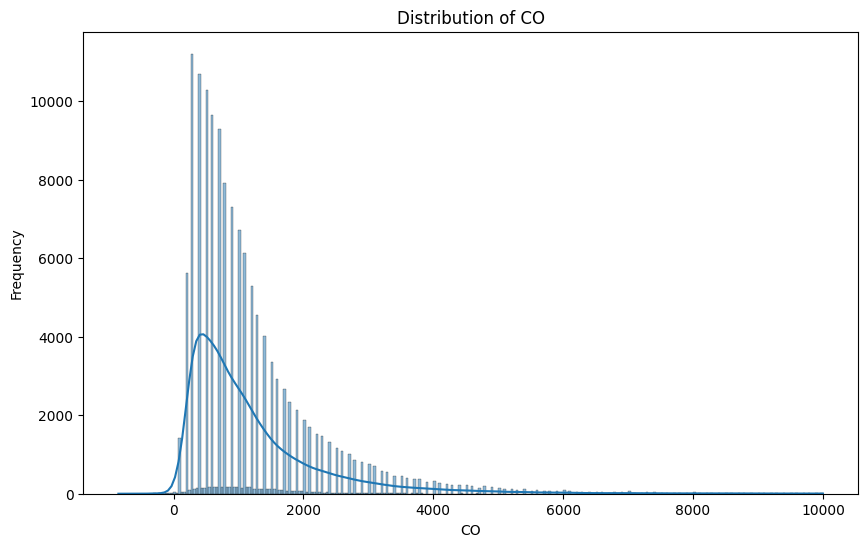

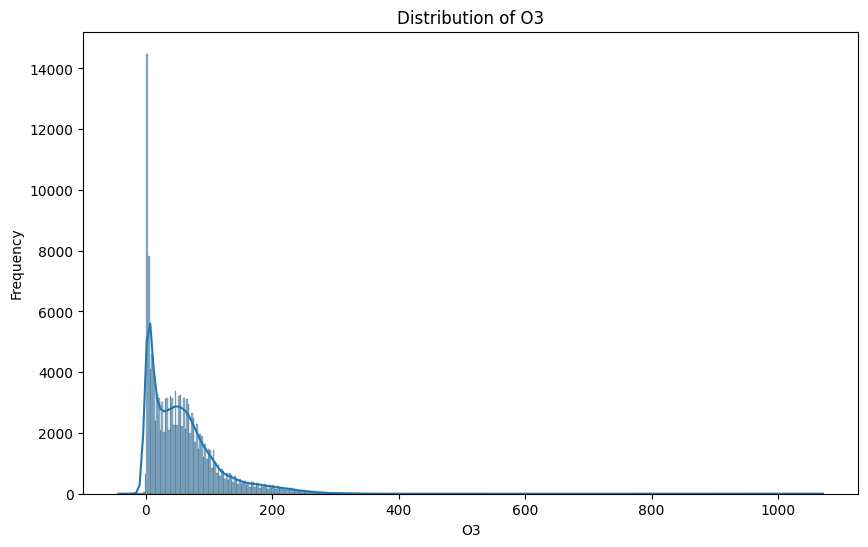

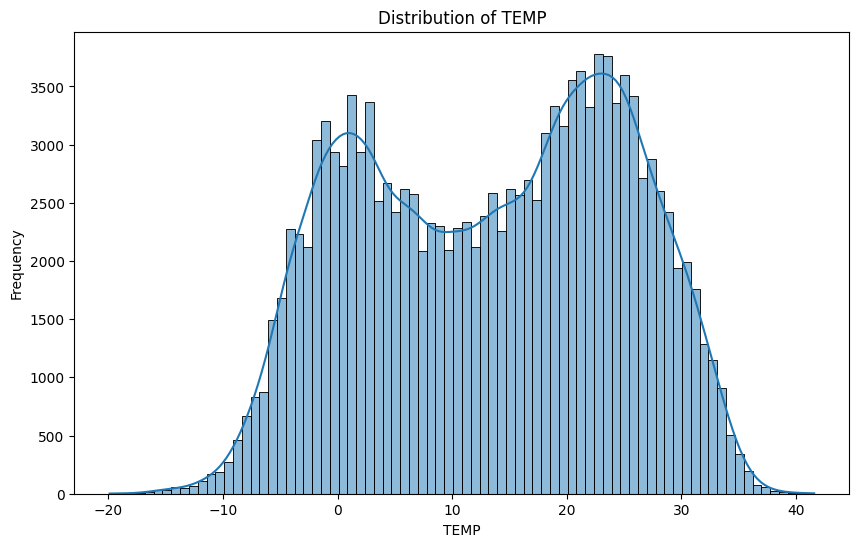

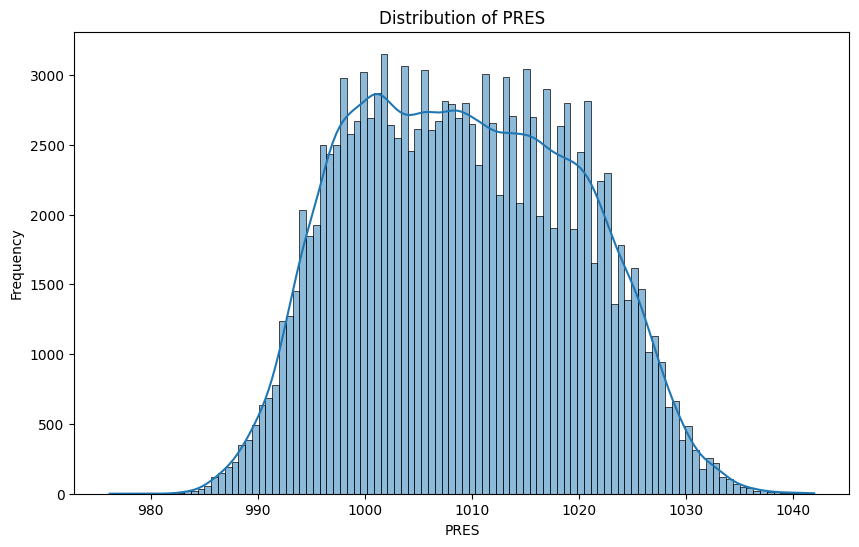

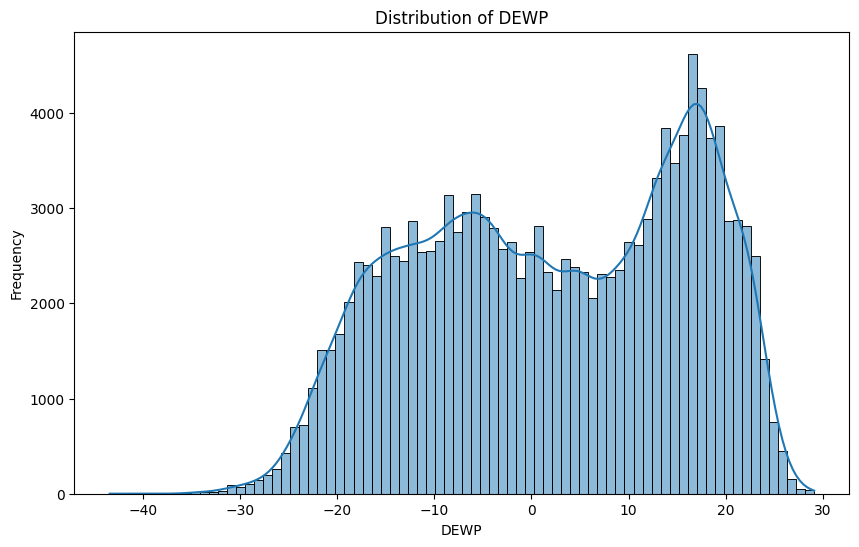

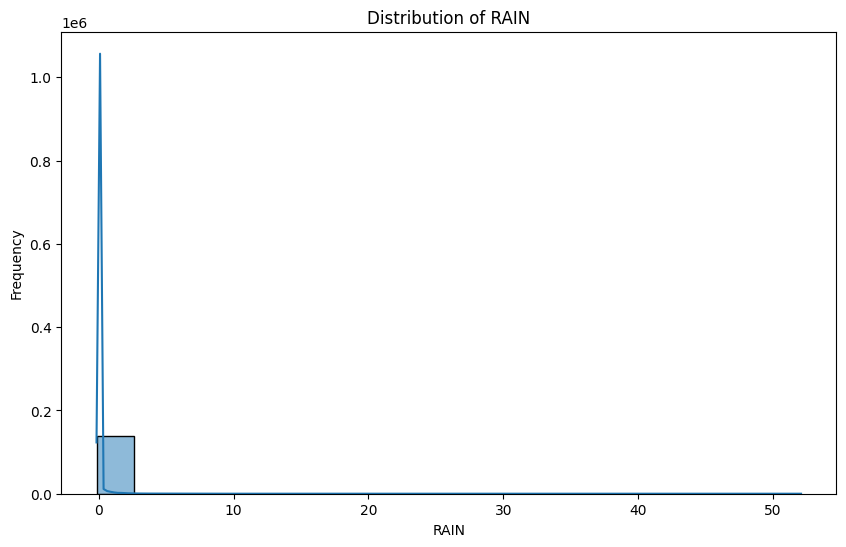

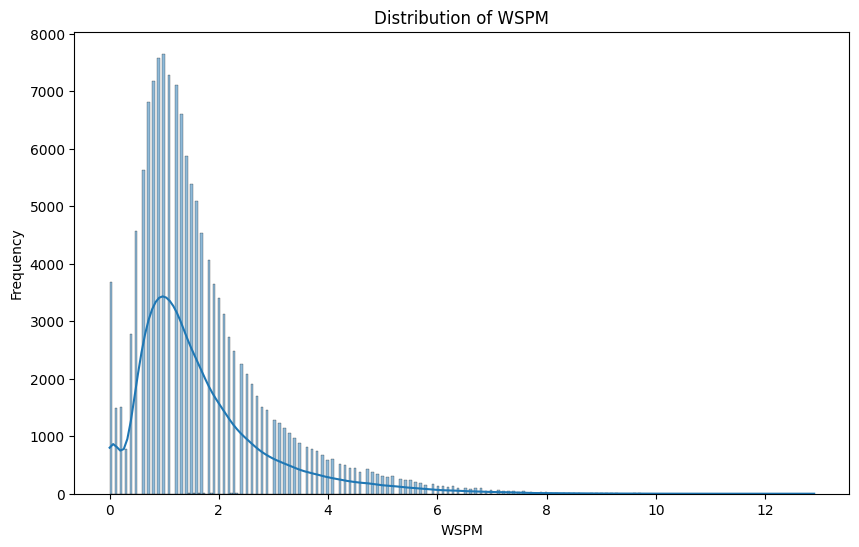

In [27]:
# generate a series of histogram plots to visualise the distribution of each component of the data.
for column in ['PM2.5', 'Coarse', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

###Distribution alanlysis
The pollutant histograms are all positively skewed so whilst the mode, background level is likely acceptable, the long tail indicates that there are times when the concentrations can reach dangerous levels which would likely cause harm to those exposed.

The rain and wind speed histograms also fiollow this trend indicating generally clement conditions with occasional outliers.

The temperature graph shows seasonal difference with peaks at 24 degees and 2 degrees for summer and winter respectively and fewer moderate temperatures in between at the 11 degrees mark.

This seasonal difference is reflected in the Dewpoint histogram and indicates a high humidity in the summer months. The winters are likely cold and dry. The lack of pronounced valley indicates a more general mumidity experience for the populace.

The pressure histogram is more symetrical showing the mean and median are roughly the same. A more evenly distributed phenomenen.

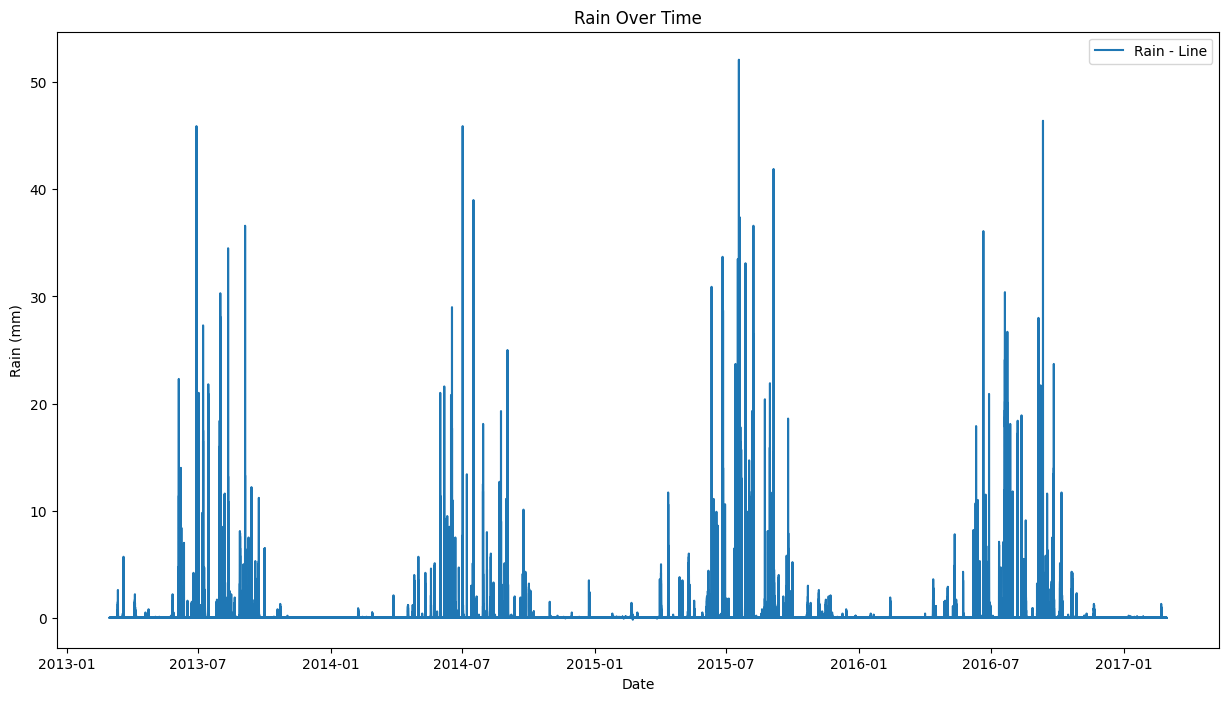

In [28]:
#plot rain over time
plt.figure(figsize=(15, 8))
plt.plot(df['datetime'], df['RAIN'], label='Rain')
plt.xlabel('Date')
plt.ylabel('Rain (mm)')
plt.title('Rain Over Time')
plt.legend()

###Correlation Heatmap

To understand the relationships between pollutants and meteorological factors, a correlation heatmap was generated. This visual representation helps identify which variables move together, which move in opposite directions, and which have little to no linear relationship.

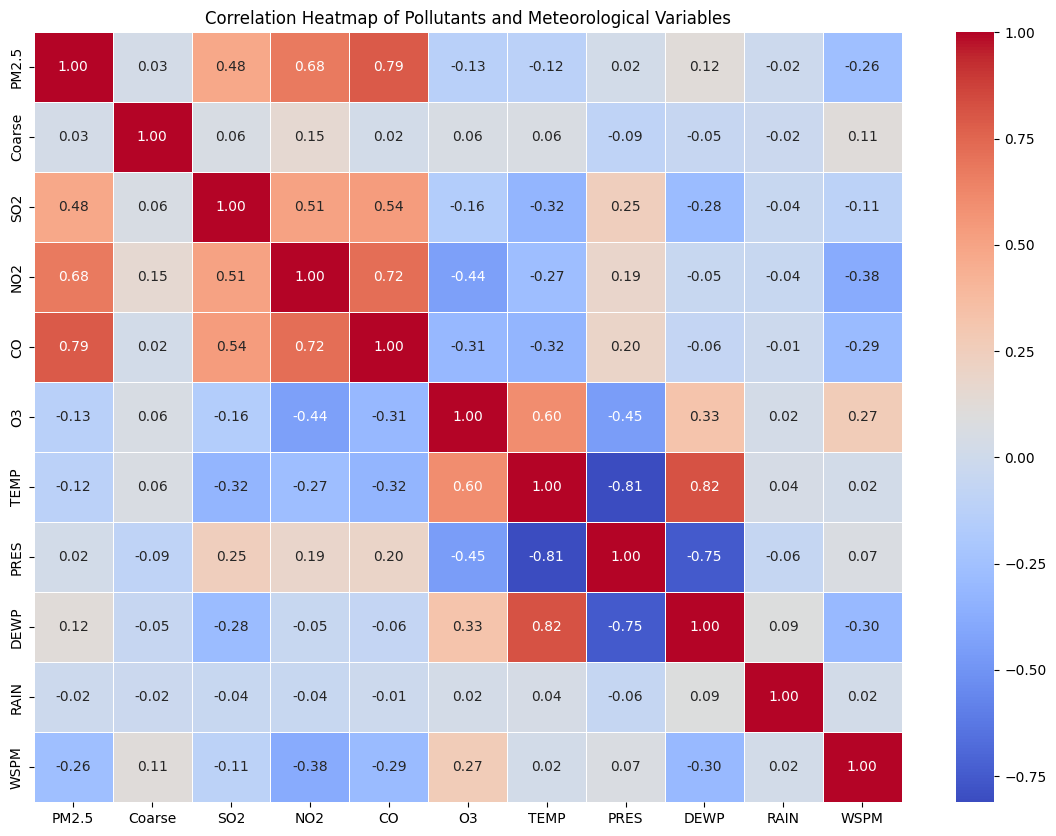

In [30]:
# columns for correlation analysis
correlation_cols = ['PM2.5', 'Coarse', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Calculate the matrix
correlation_matrix = df[correlation_cols].corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Pollutants and Meteorological data')
plt.show()

###Heatmap analysis
The first thing which jumps out when looking at the heatmap is the close correlation between PM2.5 and Carbon monoxide (CO), Nitrogen dioxide (NO2) and Sulphur dioxide (SO2). It is fair to assume that the fine particles contined in the PM2.5 reading are predominantly these hazardous chemicals and that they are likely from a similar source, industry or vehicles. This shows that moniotring PM2.5, is a reliable indicator of these pollutants in general.

Wind speed has a reasonably negative correlation with the three pollutants above, it can be concluded that being low mass they are easily carried off by the wind

Ozone (O3) correlates most highly with temperature. Ozone is formed in the air due to a chemical reaction with sunlight, hotter days indicate an increase in solar radiation, increasing O3 production. Wind speed also correlates well as it would increase available energy in the air.

As expected a higher temperature correlates with a higher Dew point as warmer air can hold more moisture.

The strong negative correlation, -0.81 between temperature and pressure illustrates the meterological phenomenen whereby high temperatures create low pressure rising air masses and cold temperatures lead to high pressure descending air.



# Task 3: Model Building:

• After completing all the tasks listed under Task 1 and Task 2, identify and implement the best practices
to build a suitable machine-learning model (e.g., feature scaling, encoding techniques, variable selection,
and parameter optimization).

• Justify your modelling decisions and evaluate model performance using appropriate metrics.


# Task 4: Application Development

Develop an interactive application with a graphical user interface (GUI). The application should include multiple
sections/pages that allow users to explore

• The dataset section,

• Visualization section, and

• Model outputs section.

You may design the structure in any way you find appropriate, but it should enable clear navigation between the

key components of your workflow

# Task 5: Version Control:

• Use GitHub for version control.

• Commit changes regularly with clear, descriptive messages, for example, added PM2.5 prediction
model”, “Created correlation heatmap,” etc.

• Maintain an organised repository structure and include screenshots of:

▫ GitHub commit history

▫ GitHub project repository layout

Links to Papers-
[Yao et al](https://www.mdpi.com/1660-4601/12/10/12264) [Xu&zhang](https://www.sciencedirect.com/science/article/pii/S0301479720301985?via%3Dihub#bib1)